# 使用医疗领域数据微调 ChatGLM3

生成带有 epoch 和 timestamp 的模型文件

In [1]:
import torch
from peft import PeftModel, PeftConfig

print(torch.__config__.show(), torch.cuda.get_device_properties(0))

PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.2 (Git Hash 2dc95a2ad0841e29db8b22fbccaf3e5da7992b01)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_61,code=sm_61;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencode;arch=compute_86,code=sm_86;-gencode;arch=compute_90,code=sm_90
  - CuDNN 8.9.2
  - Magma 2.6.1
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, CUDA_VERSION=12.1, CUDNN_VERSION=8.9.2, CXX_COMPILER=/opt/rh/devtoolset-9/root/usr/bin/c++, CXX_FLAGS= -D_GLIBCXX_USE_CXX11_ABI=0 -fabi-version=11 -fvisibility-inlines-hidden -DUS

In [2]:
# 定义全局变量和参数
model_name_or_path = 'THUDM/chatglm3-6b'  # 模型ID或本地路径
train_data_path = 'data/conversations_data.csv'    # 训练数据路径
eval_data_path = None                     # 验证数据路径，如果没有则设置为None
per_device_eval_batch_size: 16
evaluation_strategy: "steps"
eval_steps: 500
seed = 8                                 # 随机种子
max_input_length = 512                    # 输入的最大长度
max_output_length = 1536                  # 输出的最大长度
lora_rank = 16                             # LoRA秩
lora_alpha = 32                           # LoRA alpha值
lora_dropout = 0.05                       # LoRA Dropout率
prompt_text = ''                          # 所有数据前的指令文本
peft_model_path = "models/THUDM/chatglm3-6b-epoch10"

## 数据处理

In [3]:
from datasets import load_dataset

# dataset = load_dataset("csv", data_files=train_data_path)
# print(dataset)

# 假设你的JSON文件位于当前目录下的"data"文件夹中
file_path = "data/GenMedGLM-8k.json"

# 使用data_files参数指定JSON文件路径
dataset = load_dataset("json", data_files=file_path)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['input', 'instruction', 'output'],
        num_rows: 7965
    })
})


In [4]:
from datasets import ClassLabel, Sequence
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)
    
    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
        elif isinstance(typ, Sequence) and isinstance(typ.feature, ClassLabel):
            df[column] = df[column].transform(lambda x: [typ.feature.names[i] for i in x])
    display(HTML(df.to_html()))

In [5]:
show_random_elements(dataset["train"], num_examples=5)

,input,instruction,output
0,在一个房间里，有四个人，其中两个人是同性恋者，另外两个人则是异性恋者。请问这个房间里最多有多少人？\n\n,如果您是医生，请根据患者的描述回答医学问题。,在这个房间里，最多有 $4 + 2 \times 2 = 8$ 个人。其中，同性恋者和异性恋者各有两个，因此总共有 $4 + 2 = 6$ 个人。所以，这个房间里最多有 8 个人。
1,\n\n在缺氧的情况下，内皮细胞会受到哪些影响？\n\n,如果您是医生，请根据患者的描述回答医学问题。,\n\n在缺氧的情况下，内皮细胞会受到多种影响，包括：\n\n1. 内皮细胞受损：缺氧会导致细胞内代谢性酸中毒和自由基生成增多，这些损伤因素会激活细胞因子和炎症介质等，进一步损伤内皮细胞，导致内皮细胞破裂、纤维连接蛋白表达和分布异常等。\n\n2. 内皮细胞通透性增加：缺氧会导致血管壁通透性增加，内皮细胞间隙增大，从而增加血管通透性。\n\n3. 血管内皮生长因子(VEGF)表达增多：缺氧会引起VEGF的表达增多，从而诱导内皮细胞紧密连接开放，增加血管壁通透性。\n\n这些影响会导致内皮细胞出现一系列功能、代谢和结构的改变，如损伤、通透性增加等，从而影响组织、细胞的功能和代谢。
2,一位患者因骨折需要治疗，他的一位家属反对治疗，认为治疗会使病情恶化。治疗师需要采取哪些措施来与患者家属进行有效的沟通？\n\n,如果您是医生，请根据患者的描述回答医学问题。,\n\n治疗师需要采取以下措施来与患者家属进行有效的沟通：\n\n1. 尊重患者的意见：尊重患者的意见，不要强迫他们接受治疗方案。如果患者同意治疗，治疗师应该遵循他们的建议，并在治疗计划中充分考虑他们的需求。\n\n2. 强调治疗的好处：向患者家属解释治疗方案的好处，例如，它可以帮助患者尽快康复，提高生活质量等。这可以帮助患者家属更好地理解治疗方案的价值。\n\n3. 提供信息和教育：提供有关骨折治疗的信息和教育，包括治疗方案的优缺点，以及如何护理患者等。这可以帮助患者家属更好地了解病情和治疗方案。\n\n4. 与治疗师合作：与治疗师合作，共同制定一个与患者家属沟通的计划，并在治疗过程中与治疗师保持沟通，确保患者得到最佳的治疗。\n\n5. 了解患者的文化水平和语言：了解患者的文化背景和语言，以便更好地与患者家属沟通。可以使用一些语言技巧，例如使用简单的词汇和让患者参与治疗方案的制定。\n\n6. 寻求支持：如果患者家属对治疗方案持有反对态度，治疗师可以寻求其他医疗专业人员的支持，例如医生、护士或其他治疗师，以帮助患者家属更好地理解治疗方案。\n\n与患者家属的沟通是一项重要的任务，需要治疗师尊重患者的意见，提供信息和教育，与治疗师合作，并寻求支持。通过有效的沟通，可以帮助患者尽快康复，提高生活质量。
3,什么是肺动脉瓣狭窄？\n\n,如果您是医生，请根据患者的描述回答医学问题。,肺动脉瓣狭窄(preferentialreferentialreferential flow through the肺动脉瓣)是指肺动脉瓣区域的血液供应受到一定程度的限制，导致肺动脉瓣口开放不足或过度开放。这种情况通常会导致氧供应不足，产生呼吸困难、低氧血症等症状。\n\n肺动脉瓣狭窄是一种常见的心脏病，通常是由于肺动脉瓣的先天性缺陷或后天性炎症或感染引起的。肺动脉瓣狭窄也可能与其他心脏病有关，如肺动脉高压、右心衰竭等。\n\n治疗肺动脉瓣狭窄的方法包括药物治疗、手术和导管技术等。药物治疗通常包括抗血小板药物、抗凝药物和β受体阻滞剂等。手术通常是用于治疗严重的肺动脉瓣狭窄，如狭窄程度超过70%，或者伴随其他心脏病症状。导管技术包括肺动脉瓣通液和肺动脉瓣人工机械瓣置换等。
4,什么是生物标志物？它们如何预测环境污染对人类健康的影响？\n\n,如果您是医生，请根据患者的描述回答医学问题。,生物标志物是指体内产生的与发病机制有关联的关键事件的指示物，通常是分子生物标志物。它们可以通过检测和分析生物标志物来预测环境污染对人类健康的影响。例如，环境污染物可能会导致某些生物标志物的升高，这些升高的标志物可以用于预测环境污染对人类健康的潜在危害。另外，生物标志物还可以用于监测环境污染对人类健康的影响，例如通过检测生物标志物水平的变化来评估环境污染对人体健康状况的影响。


In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, trust_remote_code=True)

Setting eos_token is not supported, use the default one.
Setting pad_token is not supported, use the default one.
Setting unk_token is not supported, use the default one.


In [7]:
# tokenize_func 函数
def tokenize_func(example, tokenizer, ignore_label_id=-100):
    # 构建问题文本
    question = example['instruction'] + example['input']
    if example.get('input', None) and example['input'].strip():
        question += f'\n{example["input"]}'

    # 构建答案文本
    answer = example['output']

    # 对问题和答案文本进行tokenize处理
    q_ids = tokenizer.encode(text=question, add_special_tokens=False)
    a_ids = tokenizer.encode(text=answer, add_special_tokens=False)

    # 如果tokenize后的长度超过最大长度限制，则进行截断
    if len(q_ids) > max_input_length - 2:  # 保留空间给gmask和bos标记
        q_ids = q_ids[:max_input_length - 2]
    if len(a_ids) > max_output_length - 1:  # 保留空间给eos标记
        a_ids = a_ids[:max_output_length - 1]

    # 构建模型的输入格式
    input_ids = tokenizer.build_inputs_with_special_tokens(q_ids, a_ids)
    question_length = len(q_ids) + 2  # 加上gmask和bos标记

    # 构建标签，对于问题部分的输入使用ignore_label_id进行填充
    labels = [ignore_label_id] * question_length + input_ids[question_length:]

    return {'input_ids': input_ids, 'labels': labels}


In [8]:
column_names = dataset['train'].column_names
tokenized_dataset = dataset['train'].map(
    lambda example: tokenize_func(example, tokenizer),
    batched=False, 
    remove_columns=column_names
)

Map:   0%|          | 0/7965 [00:00<?, ? examples/s]

In [9]:
# 初始化一个计数器
total_tokens = 0

# 遍历tokenized_dataset中的所有样本
for example in tokenized_dataset:
    # 累加每个样本的input_ids长度
    total_tokens += len(example['input_ids'])

print(f"整个数据集的总token数量是: {total_tokens}")

整个数据集的总token数量是: 1751403


/home/solidus/anaconda3/envs/llm_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/solidus/anaconda3/envs/llm_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/solidus/anaconda3/envs/llm_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/solidus/anaconda3/envs/llm_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/solidus/anaconda3/envs/llm_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: Us

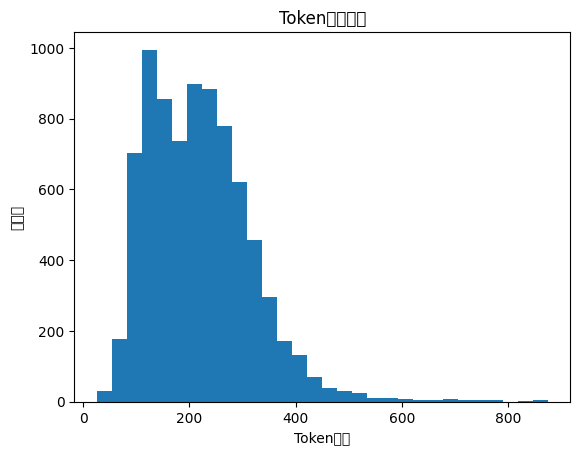

In [10]:
# 导入matplotlib进行可视化
import matplotlib.pyplot as plt

# 计算每个样本的token数量
token_lengths = [len(example['input_ids']) for example in tokenized_dataset]

# 绘制直方图
plt.hist(token_lengths, bins=30)
plt.title('Token数量分布')
plt.xlabel('Token数量')
plt.ylabel('样本数')
plt.show()

In [11]:
tokenized_dataset = tokenized_dataset.shuffle(seed=seed)
tokenized_dataset = tokenized_dataset.flatten_indices()

Flattening the indices:   0%|          | 0/7965 [00:00<?, ? examples/s]

In [12]:
import torch
from typing import List, Dict, Optional

# DataCollatorForChatGLM 类
class DataCollatorForChatGLM:
    """
    用于处理批量数据的DataCollator，尤其是在使用 ChatGLM 模型时。

    该类负责将多个数据样本（tokenized input）合并为一个批量，并在必要时进行填充(padding)。

    属性:
    pad_token_id (int): 用于填充(padding)的token ID。
    max_length (int): 单个批量数据的最大长度限制。
    ignore_label_id (int): 在标签中用于填充的ID。
    """

    def __init__(self, pad_token_id: int, max_length: int = 2048, ignore_label_id: int = -100):
        """
        初始化DataCollator。

        参数:
        pad_token_id (int): 用于填充(padding)的token ID。
        max_length (int): 单个批量数据的最大长度限制。
        ignore_label_id (int): 在标签中用于填充的ID，默认为-100。
        """
        self.pad_token_id = pad_token_id
        self.ignore_label_id = ignore_label_id
        self.max_length = max_length

    def __call__(self, batch_data: List[Dict[str, List]]) -> Dict[str, torch.Tensor]:
        """
        处理批量数据。

        参数:
        batch_data (List[Dict[str, List]]): 包含多个样本的字典列表。

        返回:
        Dict[str, torch.Tensor]: 包含处理后的批量数据的字典。
        """
        # 计算批量中每个样本的长度
        len_list = [len(d['input_ids']) for d in batch_data]
        batch_max_len = max(len_list)  # 找到最长的样本长度

        input_ids, labels = [], []
        for len_of_d, d in sorted(zip(len_list, batch_data), key=lambda x: -x[0]):
            pad_len = batch_max_len - len_of_d  # 计算需要填充的长度
            # 添加填充，并确保数据长度不超过最大长度限制
            ids = d['input_ids'] + [self.pad_token_id] * pad_len
            label = d['labels'] + [self.ignore_label_id] * pad_len
            if batch_max_len > self.max_length:
                ids = ids[:self.max_length]
                label = label[:self.max_length]
            input_ids.append(torch.LongTensor(ids))
            labels.append(torch.LongTensor(label))

        # 将处理后的数据堆叠成一个tensor
        input_ids = torch.stack(input_ids)
        labels = torch.stack(labels)

        return {'input_ids': input_ids, 'labels': labels}


In [13]:
# 准备数据整理器
data_collator = DataCollatorForChatGLM(pad_token_id=tokenizer.pad_token_id)

## 加载模型

In [14]:
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig
_compute_dtype_map = {
    'fp32': torch.float32,
    'fp16': torch.float16,
    'bf16': torch.bfloat16
}

# QLoRA 量化配置
q_config = BitsAndBytesConfig(load_in_4bit=True,
                              bnb_4bit_quant_type='nf4',
                              bnb_4bit_use_double_quant=True,
                              bnb_4bit_compute_dtype=_compute_dtype_map['bf16'])
# 加载量化后模型
base_model = AutoModel.from_pretrained(model_name_or_path,
                                  quantization_config=q_config,
                                  device_map='auto',
                                  trust_remote_code=True)

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [15]:
# 加载量化后模型
config = PeftConfig.from_pretrained(peft_model_path)
model = PeftModel.from_pretrained(base_model, peft_model_path)

In [16]:
from peft import TaskType, LoraConfig, get_peft_model, prepare_model_for_kbit_training
from peft.utils import TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING

kbit_model = prepare_model_for_kbit_training(model)
target_modules = TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING['chatglm']

In [17]:
target_modules

['query_key_value']

In [18]:
lora_config = LoraConfig(
    target_modules=target_modules,
    r=lora_rank,
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    bias='none',
    inference_mode=False,
    task_type=TaskType.CAUSAL_LM
)

In [19]:
qlora_model = get_peft_model(kbit_model, lora_config)
qlora_model.print_trainable_parameters()

trainable params: 3,899,392 || all params: 6,247,483,392 || trainable%: 0.06241540401681151


### QLoRA 微调模型

In [20]:
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

train_epochs = 1
# output_dir = f"models/{model_name_or_path}-epoch{train_epochs}-{timestamp}"
output_dir = f"models/{model_name_or_path}-epoch{train_epochs}-medical"

In [21]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir=output_dir,                            # 输出目录
    per_device_train_batch_size=1,                     # 每个设备的训练批量大小
    gradient_accumulation_steps=1,                     # 梯度累积步数
    learning_rate=1e-3,                                # 学习率
    num_train_epochs=train_epochs,                     # 训练轮数
    lr_scheduler_type="linear",                        # 学习率调度器类型
    warmup_ratio=0.1,                                  # 预热比例
    logging_steps=100,                                 # 日志记录步数
    save_strategy="steps",                             # 模型保存策略
    save_steps=500,                                    # 模型保存步数
    optim="adamw_torch",                               # 优化器类型
    fp16=True,                                        # 是否使用混合精度训练
)


In [22]:
trainer = Trainer(
        model=qlora_model,
        args=training_args,
        train_dataset=tokenized_dataset,
        data_collator=data_collator
    )

In [23]:
# trainer.train()

In [24]:
trainer.train(resume_from_checkpoint=True)

Step,Training Loss
5600,1.591900
5700,1.540700
5800,1.480100
5900,1.491400
6000,1.530100
6100,1.550700
6200,1.580300
6300,1.556300
6400,1.454700
6500,1.482000


TrainOutput(global_step=7965, training_loss=0.4745450754399129, metrics={'train_runtime': 8376.7713, 'train_samples_per_second': 0.951, 'train_steps_per_second': 0.951, 'total_flos': 6.284512355550413e+16, 'train_loss': 0.4745450754399129, 'epoch': 1.0})

In [25]:
trainer.model.save_pretrained(output_dir)

In [36]:
response, history = trainer.model.chat(tokenizer, query="在缺氧的情况下，内皮细胞会受到哪些影响？")
print(response)

在缺氧的情况下，内皮细胞会受到以下影响：

1. 内皮细胞生存环境的改变：缺氧会导致内皮细胞生存环境发生改变，例如缺氧、低氧、低酸等，这些因素会影响内皮细胞的生长、分化、修复和更新。

2. 内皮细胞的结构和功能改变：缺氧会导致内皮细胞的结构和功能发生改变，例如内皮细胞的通透性增加、内皮细胞的运动能力增强等，这些变化会对内皮细胞的生存和功能产生影响。

3. 内皮细胞的生长和修复：缺氧会导致内皮细胞的生长和修复受到抑制，内皮细胞会受到损伤和死亡，从而导致血管病变的发生。

4. 内皮细胞的生长和分化：缺氧会影响内皮细胞的生长和分化，例如内皮细胞的数量、形态、结构和功能等，这些变化会对内皮细胞的生存和功能产生影响。

缺氧会影响内皮细胞的生存和功能，导致血管病变的发生。因此，应该采取措施减轻缺氧的影响，例如增加氧气供应、改善氧气供应、提高氧气浓度等。


In [37]:
response, history = trainer.model.chat(tokenizer, query="中国的首都和美国的首都分别是哪里？")
print(response)

中国的首都和美国的首都分别是北京和华盛顿。


In [45]:
response, history = trainer.model.chat(tokenizer, query="什么是肺动脉瓣狭窄？")
print(response)

肺动脉瓣狭窄是一种心脏疾病，导致肺动脉瓣狭窄，使肺动脉血流不足，从而导致呼吸困难和运动不耐受等症状。肺动脉瓣狭窄通常由肺动脉瓣狭窄和肺动脉瓣关闭不全两种情况引起，其中肺动脉瓣狭窄通常会导致肺动脉瓣关闭不全，而肺动脉瓣关闭不全通常会导致肺动脉瓣狭窄。

肺动脉瓣狭窄的常见原因包括肺动脉瓣膜狭窄、肺动脉瓣膜关闭不全、肺动脉瓣膜增厚等。治疗肺动脉瓣狭窄的方法包括药物治疗、手术治疗和介入治疗等。药物治疗通常包括抗凝药物、利尿剂和血管扩张剂等，手术治疗包括肺动脉瓣切开术和肺动脉瓣重建术等，介入治疗包括肺动脉瓣狭窄术和肺动脉瓣狭窄术等。治疗肺动脉瓣狭窄需要根据患者的具体情况制定个体化的治疗方案。
